# 1. EDA Overview

**Project:** Predicting Rural Water Point Functionality Using Data Mining

**Target variable:** `functional3` (Functional / Partially functional / Abandoned or not functional)

**Task:** Multiclass classification

This notebook performs a **detailed exploratory data analysis (EDA)** of the raw dataset. The goal is to understand the data's structure and meaning, investigate relationships between variables, identify data-quality issues (missing values, duplicates, outliers), examine class imbalance, and flag variables that may cause **data leakage**.

**This notebook does not modify the raw dataset, remove columns, treat outliers, encode variables, or train models.** All findings are observations to inform decisions made later in the preprocessing stage.

In [1]:
# Core libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load the raw dataset (relative path — works from the notebooks/ folder on any machine)
DATA_PATH = "../data/raw/water_pump_functionality.xlsx"
TARGET = "functional3"

df = pd.read_excel(DATA_PATH)

# Fixed, readable order for the three target classes (used throughout this notebook)
CLASS_ORDER = ["Functional", "Partially functional", "Abandoned or not functional"]

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1793 rows, 52 columns


# 2. Dataset Structure

Recap the shape and general structure of the dataset before going deeper.

In [2]:
# Shape: (rows, columns)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Data type counts across all columns
print("\nData type counts:")
print(df.dtypes.value_counts())

Shape: 1793 rows x 52 columns

Data type counts:
str        32
float64    19
int64       1
Name: count, dtype: int64


In [3]:
# Number of unique values per column — a quick way to spot identifiers
# (very high uniqueness) and near-constant columns (very low uniqueness).
# Shown as a compact summary rather than one print per column.
nunique_summary = df.nunique().sort_values(ascending=False)
nunique_summary.to_frame("n_unique")

,n_unique
id,1793
instance_wp,1793
photo_wp,1792
longitude_wp,1766
latitude_wp,1764
commid_wp,1395
elevation_wp,1387
pop_1000,1159
cwid,948
minutesfill20l,625


# 3. Variable Types

Split the columns into **numerical** and **categorical** groups so the rest of the notebook can analyze each group appropriately.

- `id` is an identifier column and is excluded from analysis (it carries no predictive information).
- `functional3` is the target variable and is analyzed separately in Section 4.

In [4]:
# Numerical columns (excluding the 'id' identifier column)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "id"]

# Categorical (text) columns, excluding the target
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in ["id", TARGET]]

print(f"Numerical columns ({len(numeric_cols)}):")
print(numeric_cols)

print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical columns (19):
['latitude_wp', 'longitude_wp', 'elevation_wp', 'qtyhh_wp', 'wp_age', 'rehab_age', 'qtypeople_wp', 'minutesfill20l', 'brokendays_wp', 'qtymonthsnowater_wp', 'pumpstrokes', 'grant_number_wp', 'balance_any_dollars_wp', 'improved_wponly_wp', 'qtyhh_c_wp', 'wc_savings_wp', 'wpqty_wp', 'pop_1000', 'annual_rain']

Categorical columns (31):
['country', 'admin1', 'admin2', 'admin3', 'instance_wp', 'subdate_wp', 'commid_wp', 'dataorg_wp', 'timepoint_wp', 'cwfunded_wp', 'cwid', 'wptype', 'pumptype', 'drillmethod', 'piped_source', 'piped_pump', 'rehabyn', 'whomanage_wp', 'wateravailable', 'whynowatertoday_wp', 'whynowatertoday_wp_other', 'downtime2weeks', 'lockedfullday_wp', 'photo_wp', 'wc_present_wp', 'paytocollect_wp', 'wc_admin_index_wp', 'wc_finance_index_wp', 'wc_mgmt_index_wp', 'wc_maint_index_wp', 'season']


# 4. Target Variable Analysis

Examine the distribution of `functional3` — the variable we are trying to predict.

In [5]:
# Class counts and percentages
target_counts = df[TARGET].value_counts().reindex(CLASS_ORDER)
target_pct = (df[TARGET].value_counts(normalize=True) * 100).reindex(CLASS_ORDER).round(2)

target_summary = pd.DataFrame({"count": target_counts, "percentage": target_pct})
target_summary

,count,percentage
functional3,,
Functional,1333,74.34
Partially functional,157,8.76
Abandoned or not functional,303,16.90


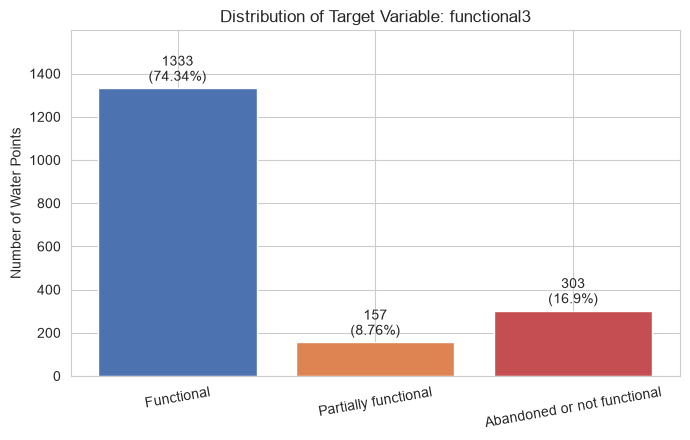

In [6]:
# Visualize the target distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(target_summary.index, target_summary["count"], color=["#4C72B0", "#DD8452", "#C44E52"])

# Annotate each bar with its count and percentage
for bar, count, pct in zip(bars, target_summary["count"], target_summary["percentage"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

ax.set_title("Distribution of Target Variable: functional3")
ax.set_ylabel("Number of Water Points")
ax.set_ylim(0, target_summary["count"].max() * 1.2)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Observation:** The target is clearly **imbalanced**. "Functional" accounts for 1,333 records (74.34%), while "Abandoned or not functional" (303, 16.90%) and especially "Partially functional" (157, 8.76%) are much rarer. A model that always predicts "Functional" would already be "correct" nearly 3 out of 4 times, so accuracy alone will be a misleading metric — this has implications for both evaluation metrics and, potentially, class-imbalance handling later on.

# 5. Missing Value Analysis

Build a complete missing-value summary (count and percentage per column), visualize it, and look for columns whose missingness seems to follow a meaningful pattern rather than being random.

In [7]:
# Missing value count and percentage per column, sorted by percentage (highest first)
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_pct})

print(f"{len(missing_summary)} of {df.shape[1]} columns have at least one missing value.")
missing_summary

40 of 52 columns have at least one missing value.


,missing_count,missing_percent
whynowatertoday_wp_other,1775,99.00
rehab_age,1513,84.38
whynowatertoday_wp,1491,83.16
grant_number_wp,1246,69.49
piped_source,1219,67.99
piped_pump,1219,67.99
brokendays_wp,1160,64.70
balance_any_dollars_wp,853,47.57
cwid,834,46.51
pumpstrokes,818,45.62


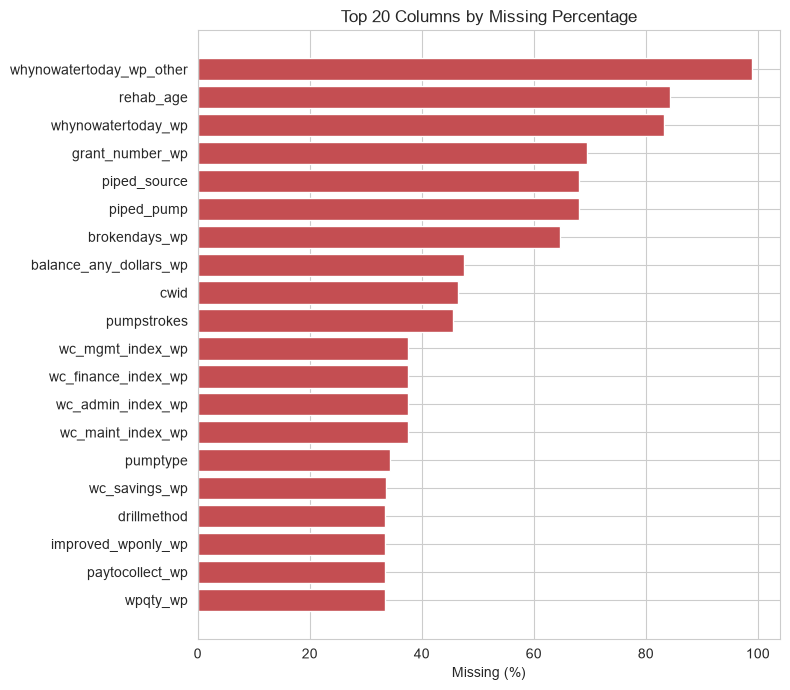

In [8]:
# Visualize missingness — top 20 columns by missing percentage
fig, ax = plt.subplots(figsize=(8, 7))
top_missing = missing_summary.head(20).sort_values("missing_percent")
ax.barh(top_missing.index, top_missing["missing_percent"], color="#C44E52")
ax.set_xlabel("Missing (%)")
ax.set_title("Top 20 Columns by Missing Percentage")
plt.tight_layout()
plt.show()

### Investigating whether missingness is contextual

Several heavily-missing columns look like they might only apply to a *subset* of water points (e.g. rehabilitation details only make sense if a water point was actually rehabilitated). We check this directly instead of assuming it.

In [9]:
# rehab_age (84.4% missing overall) is 'years since last rehabilitation'.
# Check whether it is missing specifically when rehabyn ('was it ever rehabilitated?') is 'No'.
(df.groupby("rehabyn", dropna=False)["rehab_age"]
   .apply(lambda s: s.isnull().mean() * 100)
   .round(2)
   .rename("rehab_age missing %")
   .to_frame())

,rehab_age missing %
rehabyn,
No,100.00
Yes,0.36
NaN,100.00


**Observation:** `rehab_age` is missing for **100%** of records where `rehabyn` is "No" (never rehabilitated) and missing for only **0.36%** of records where `rehabyn` is "Yes". This is **not random missingness (MCAR)** — it is **structurally missing**: the value simply does not apply when no rehabilitation happened. The same logic likely explains other heavily-missing "detail" columns tied to a conditional event (e.g. `piped_source`/`piped_pump` only apply to piped water points, `whynowatertoday_wp` only applies when water is currently unavailable — see Section 12 for the latter). This distinction matters for preprocessing: these are not gaps to "fix" with a generic imputation strategy, but a signal that a categorical "Not applicable" encoding may be more appropriate than mean/mode imputation.

# 6. Duplicate Analysis

Check for fully duplicated rows.

In [10]:
# Fully duplicated rows (every column identical)
n_duplicates = df.duplicated().sum()
duplicate_pct = round(n_duplicates / len(df) * 100, 2)

print(f"Duplicate rows: {n_duplicates}")
print(f"Duplicate percentage: {duplicate_pct}%")

Duplicate rows: 0
Duplicate percentage: 0.0%


**Observation:** No fully duplicated rows were found (0.0%). Duplicate handling is not a concern for this dataset at this stage.

# 7. Numerical Variable Analysis

Rather than profiling all 19 numerical columns (many are administrative indices, geographic coordinates, or have very high missingness), we focus on the numerical variables most relevant to understanding water-point functionality:

- `wp_age` — age of the water point (years)
- `rehab_age` — years since last rehabilitation
- `qtypeople_wp` / `qtyhh_wp` — people / households served
- `annual_rain` — annual rainfall at the site (mm)
- `elevation_wp` — elevation of the site (m)
- `pop_1000` — population within 1 km
- `minutesfill20l`, `brokendays_wp`, `qtymonthsnowater_wp`, `pumpstrokes` — usage/downtime metrics (revisited more closely in Section 12, since these describe *current* water availability and are leakage candidates)

In [11]:
# Key numerical variables for this analysis
key_numeric = ["wp_age", "rehab_age", "qtypeople_wp", "qtyhh_wp", "annual_rain",
               "elevation_wp", "pop_1000", "minutesfill20l", "brokendays_wp",
               "qtymonthsnowater_wp", "pumpstrokes"]

# Descriptive statistics: count, mean, std, min, quartiles, max
desc = df[key_numeric].describe().T
desc["skew"] = df[key_numeric].skew()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
wp_age,1776.0,4.61,6.49,0.50,1.00,3.00,4.00,74.00,4.14
rehab_age,280.0,2.49,1.75,0.50,1.00,2.00,3.00,12.00,1.91
qtypeople_wp,1755.0,347.03,422.97,0.00,98.50,250.00,455.00,5000.00,3.84
qtyhh_wp,1738.0,60.71,71.43,0.00,15.00,45.00,80.00,800.00,3.30
annual_rain,1246.0,996.46,395.78,601.00,601.00,1007.00,1286.00,1689.00,0.47
elevation_wp,1658.0,929.64,774.58,-217.00,303.50,684.72,1613.63,4493.70,0.60
pop_1000,1229.0,931.88,1041.59,31.78,259.36,568.34,1316.67,9412.56,2.96
minutesfill20l,1473.0,10.67,70.09,0.20,1.02,1.30,1.85,555.00,7.65
brokendays_wp,633.0,156.78,367.25,0.00,3.00,10.00,120.00,3650.00,4.32
qtymonthsnowater_wp,1624.0,0.56,2.06,0.00,0.00,0.00,0.00,12.00,4.43


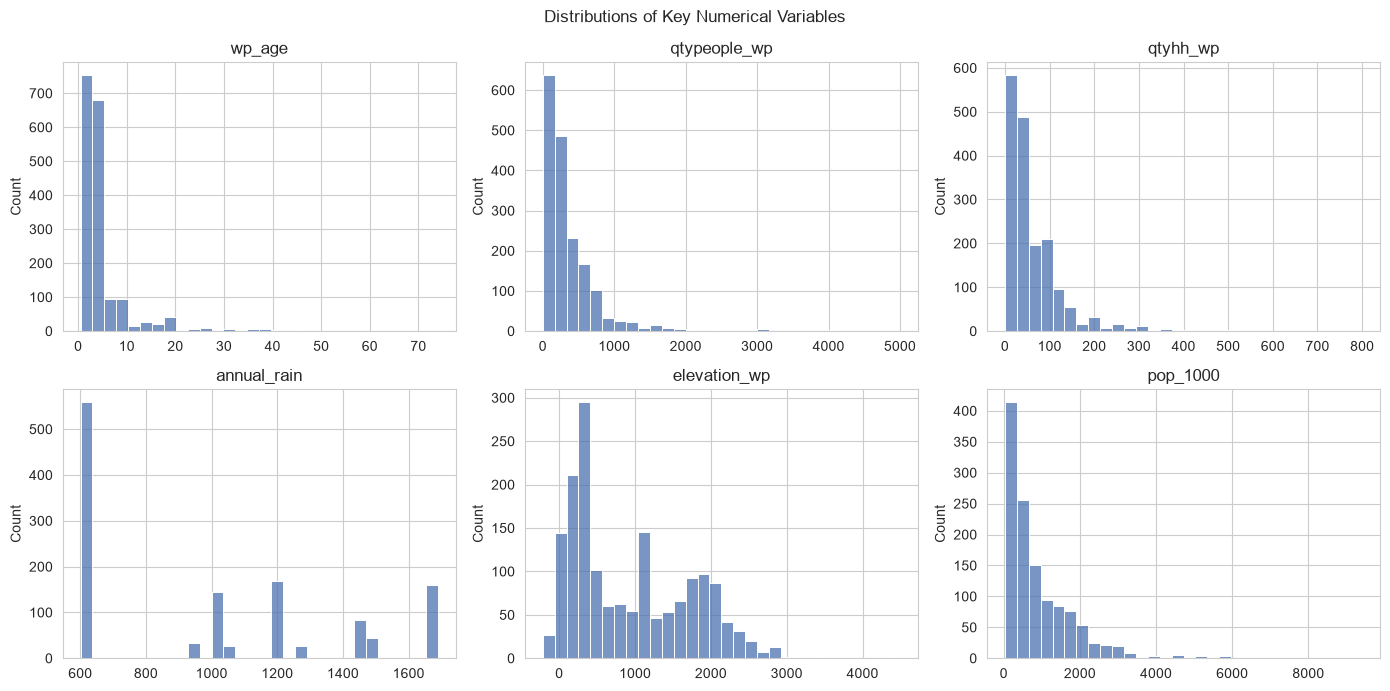

In [12]:
# Histograms for the core structural/context variables (not the leakage-candidate ones,
# which get dedicated attention in Section 12)
core_numeric = ["wp_age", "qtypeople_wp", "qtyhh_wp", "annual_rain", "elevation_wp", "pop_1000"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, core_numeric):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distributions of Key Numerical Variables")
plt.tight_layout()
plt.show()

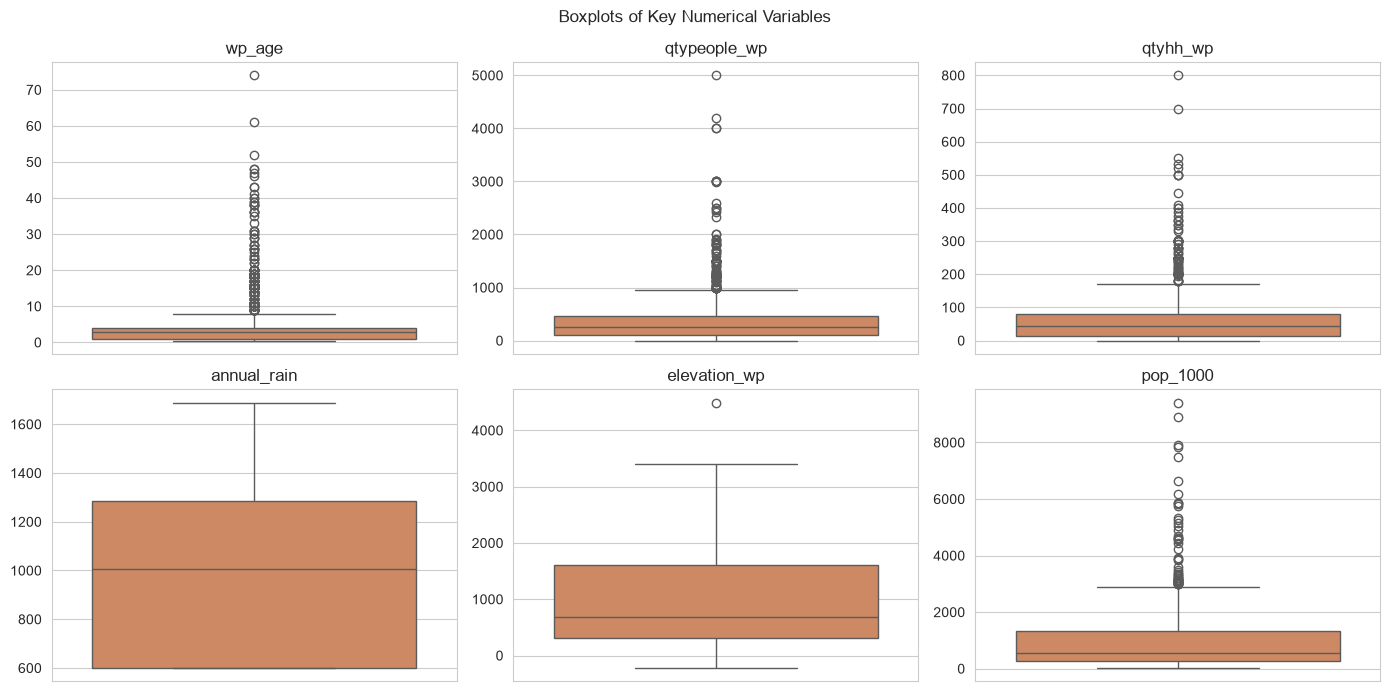

In [13]:
# Boxplots for the same variables — useful for spotting spread and extreme values
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, core_numeric):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="#DD8452")
    ax.set_title(col)
    ax.set_ylabel("")
plt.suptitle("Boxplots of Key Numerical Variables")
plt.tight_layout()
plt.show()

**Observations:**
- `wp_age`, `qtypeople_wp`, and `qtyhh_wp` are all **strongly right-skewed** (skew 3.3–4.1): most water points are young and serve modest populations, with a long tail of much older or much larger sites (e.g. `wp_age` up to 74 years, `qtypeople_wp` up to 5,000).
- `annual_rain` and `elevation_wp` are much closer to symmetric (skew 0.47 and 0.60), consistent with them being physical/geographic measurements rather than counts.
- `elevation_wp` has a minimum of **-217 m**, which is below sea level — geographically possible in low-lying rift-valley areas but unusual enough to flag for closer checking in Section 9 (Outlier Investigation).
- `pop_1000` is also right-skewed (skew 2.96), reflecting that most sites are in modestly populated areas with a few near dense population centers.

# 8. Categorical Variable Analysis

We focus on the categorical variables most likely to be meaningful predictors of functionality: `country`, `wptype`, `pumptype`, `drillmethod`, `rehabyn`, `whomanage_wp`, and `season`.

For each, we look at the number of categories, category frequencies, and any rare or inconsistent-looking categories.

In [14]:
key_categorical = ["country", "wptype", "pumptype", "drillmethod", "rehabyn", "whomanage_wp", "season"]

# Number of categories per variable
for col in key_categorical:
    print(f"{col}: {df[col].nunique()} categories, {df[col].isnull().sum()} missing")

country: 9 categories, 0 missing
wptype: 9 categories, 0 missing
pumptype: 7 categories, 616 missing
drillmethod: 3 categories, 601 missing
rehabyn: 2 categories, 367 missing
whomanage_wp: 11 categories, 1 missing
season: 2 categories, 547 missing


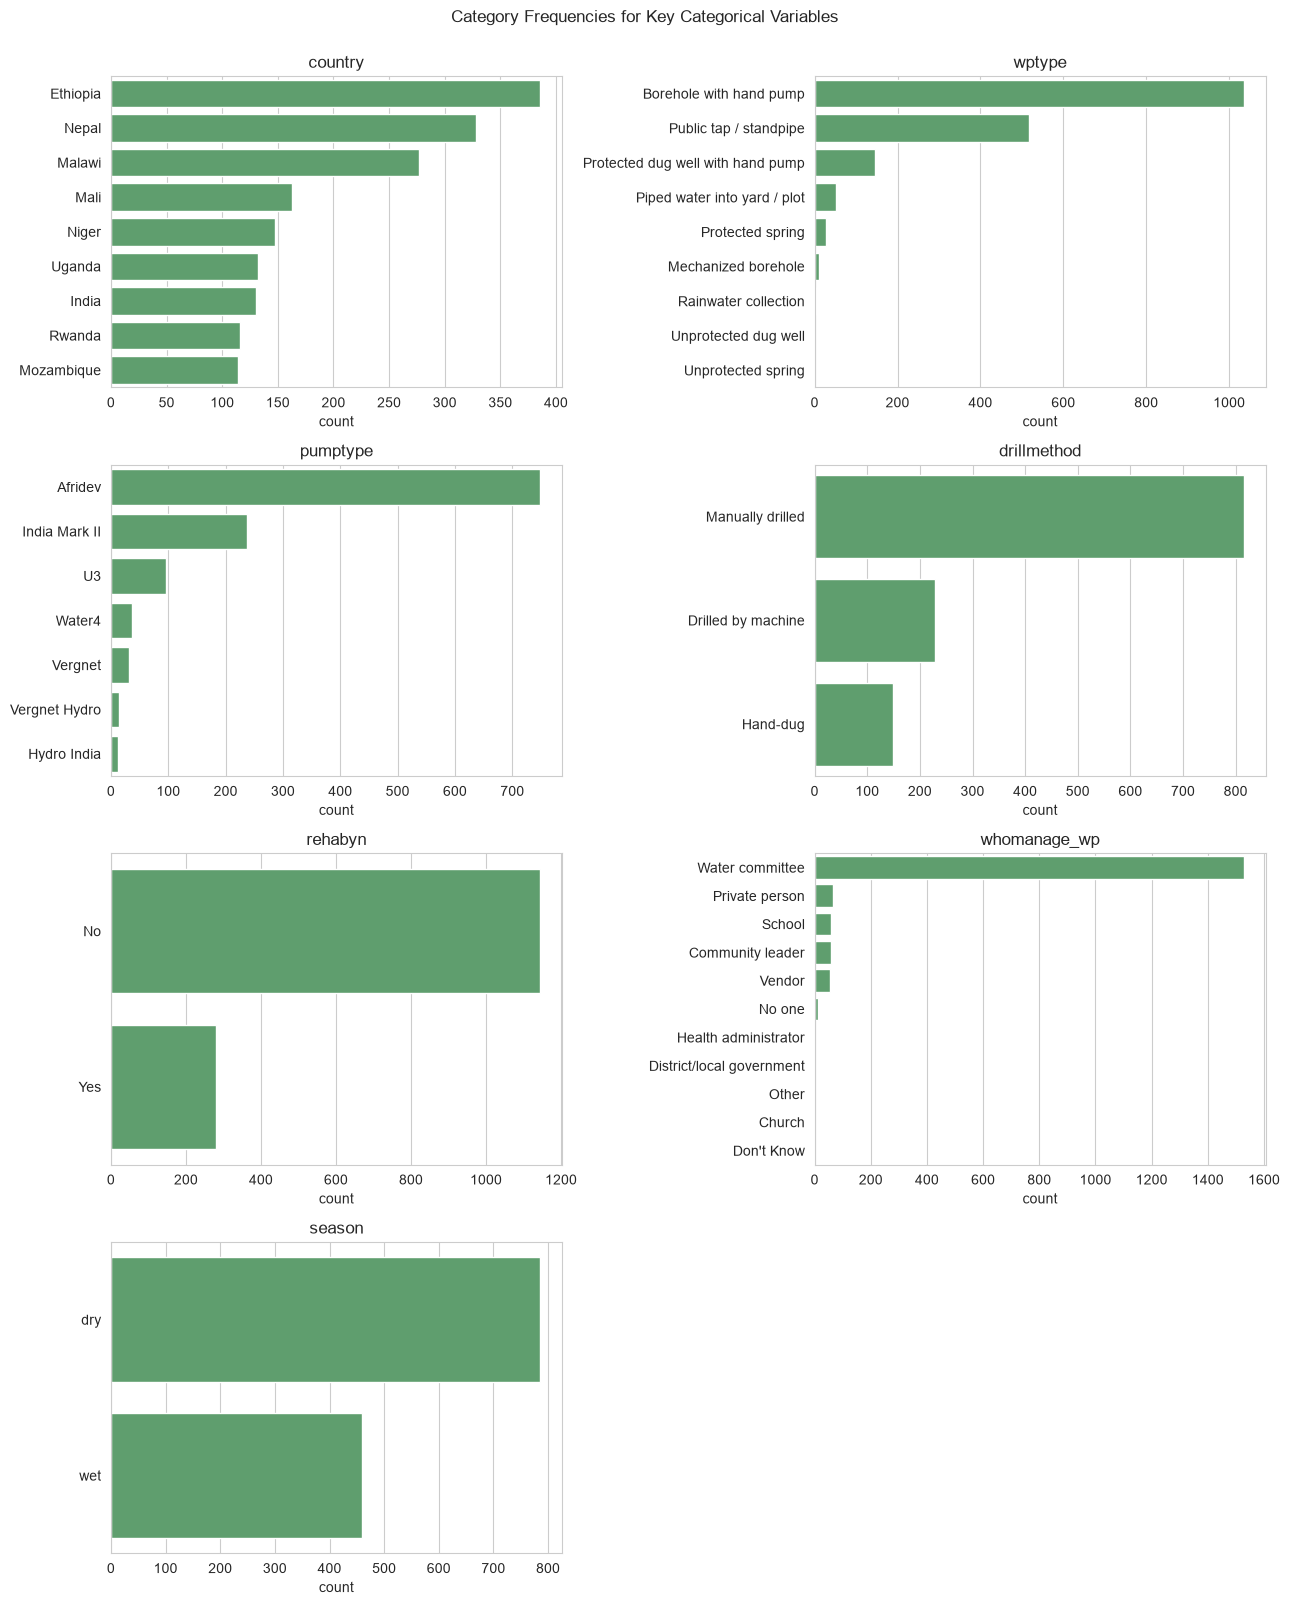

In [15]:
# Bar charts of category frequencies for each key categorical variable
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.flat, key_categorical):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#55A868")
    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("count")

# Remove the unused 8th subplot (we only have 7 variables)
fig.delaxes(axes.flat[-1])
plt.suptitle("Category Frequencies for Key Categorical Variables", y=1.0)
plt.tight_layout()
plt.show()

**Observations on categories and rare values:**
- `country`: 9 categories, ranging from Ethiopia (386 records) down to Mozambique (114). No missing values. No obviously inconsistent labels.
- `wptype`: 9 categories dominated by "Borehole with hand pump" (1,036) and "Public tap / standpipe" (516). Several categories are **very rare** — "Rainwater collection" (4), "Unprotected dug well" (2), "Unprotected spring" (1) — so any statistics computed on these categories (e.g. in Section 10) are based on very few observations and should be treated cautiously.
- `pumptype`: 34.4% missing (616 records) — this is expected, since not all water point types use a pump (e.g. protected springs, rainwater collection). Dominated by "Afridev" (749) and "India Mark II" (238).
- `drillmethod`: 33.5% missing, for the same reason (only applies to drilled water points). "Manually drilled" (816) is most common.
- `rehabyn`: binary (Yes/No) with 20.5% missing. "No" (1,145) far outweighs "Yes" (281).
- `whomanage_wp`: 11 categories, heavily dominated by "Water committee" (1,529, ~85%). Categories like "Church" (2), "Other" (2), "Health administrator" (3), "District/local government" (2) are extremely rare.
- `season`: binary (dry/wet) with 30.5% missing. "dry" (786) is more common than "wet" (460) among non-missing records.

No categories look like data-entry inconsistencies (e.g. inconsistent capitalization or obvious typos) — the categories appear to come from a controlled survey form.

# 9. Outlier Investigation

We use the IQR (interquartile range) rule as a starting point to flag potentially unusual values, then look at the actual extreme values before drawing any conclusion. **No values are removed or changed** — each finding is only classified for later attention.

In [16]:
# For each key numerical variable, count how many values fall outside 1.5*IQR from the quartiles
outlier_rows = []
for col in key_numeric:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_rows.append({
        "variable": col, "n": len(s), "min": s.min(), "max": s.max(),
        "iqr_lower": round(lower, 2), "iqr_upper": round(upper, 2),
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(s) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index("variable")
outlier_summary

,n,min,max,iqr_lower,iqr_upper,n_outliers,pct_outliers
variable,,,,,,,
wp_age,1776,0.500000,74.000000,-3.50,8.50,202,11.37
rehab_age,280,0.500000,12.000000,-2.00,6.00,9,3.21
qtypeople_wp,1755,0.000000,5000.000000,-436.25,989.75,99,5.64
qtyhh_wp,1738,0.000000,800.000000,-82.50,177.50,98,5.64
annual_rain,1246,601.000000,1689.000000,-426.50,2313.50,0,0.00
elevation_wp,1658,-217.000000,4493.700000,-1661.70,3578.83,1,0.06
pop_1000,1229,31.781268,9412.559168,-1326.62,2902.65,52,4.23
minutesfill20l,1473,0.200000,555.000000,-0.23,3.10,141,9.57
brokendays_wp,633,0.000000,3650.000000,-172.50,295.50,108,17.06


In [17]:
# Closer look at the lowest elevation values (elevation_wp min = -217 m, below sea level)
df.nsmallest(5, "elevation_wp")[["id", "country", "admin1", "elevation_wp"]]

,id,country,admin1,elevation_wp
1087,1088,Mali,Segou,-217.0
918,919,India,West Bengal,-160.0
958,959,India,West Bengal,-77.0
900,901,India,West Bengal,-73.0
929,930,India,West Bengal,-73.0


In [18]:
# How many records have negative elevation, and where are they concentrated?
n_negative_elev = (df["elevation_wp"] < 0).sum()
print(f"Records with elevation_wp < 0: {n_negative_elev}")
df.loc[df["elevation_wp"] < 0, "country"].value_counts()

Records with elevation_wp < 0: 107


country
India    106
Mali       1
Name: count, dtype: int64

### Outlier classification

| Variable | Extreme value(s) observed | Classification | Notes |
|---|---|---|---|
| `wp_age` | up to 74 years | Potentially valid extreme observation | Old but plausible; distribution is naturally right-skewed, so IQR flags many points that are simply "old", not erroneous. |
| `qtypeople_wp` / `qtyhh_wp` | up to 5,000 people / 800 households | Requires further investigation | Could be legitimate large communal water points, or could reflect rounding/estimation conventions in the survey. Correlation between the two (0.82) is consistent with genuine reporting rather than random error. |
| `minutesfill20l` | up to 555 minutes (~9.25 hours) | Requires further investigation | Extremely slow for a 20L container; plausible only for a nearly-dry/failing source. Closely tied to functionality — see Section 12. |
| `brokendays_wp` | up to 3,650 days (10 years) | Potentially valid extreme observation | Consistent with a water point that has been broken/abandoned for a very long time without being decommissioned in records. Also a leakage candidate — see Section 12. |
| `elevation_wp` | min -217 m; 107 records with negative elevation (106 in West Bengal, India) | Potential data-quality issue | West Bengal is a low-lying delta region near sea level, not consistent with values down to -160 m. The concentration of negative values in a single region suggests a systematic artifact (e.g. from an elevation lookup/DEM source) rather than 107 independently erroneous field measurements. |
| `pop_1000` | up to ~9,413 | Potentially valid extreme observation | Plausible for sites near dense population centers; right-skewed but not internally inconsistent. |
| `pumpstrokes` | up to 95 | Requires further investigation | Most values cluster at 1–3; a jump to 95 could be a genuine hard-to-pump borehole or a data-entry unit inconsistency. |

No outlier removal or transformation is performed here — these classifications are meant to guide decisions in the preprocessing stage.

# 10. Feature vs Target Analysis

We look at how selected predictor variables relate to `functional3`. All relationships described here are **associations observed in the data**, not claims of causation.

### Categorical features vs target

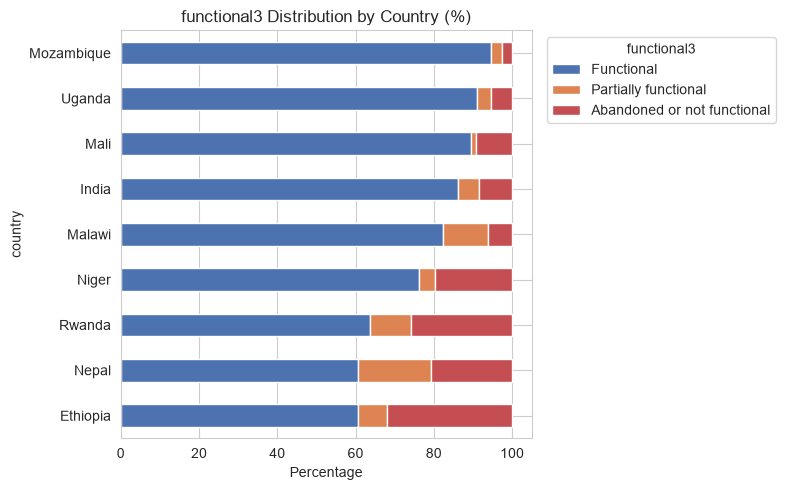

In [19]:
# country vs functional3 — percentage of each country's water points in each class
country_ct = pd.crosstab(df["country"], df[TARGET], normalize="index")[CLASS_ORDER] * 100
country_ct = country_ct.sort_values("Functional")

country_ct.plot(kind="barh", stacked=True, figsize=(8, 5),
                 color=["#4C72B0", "#DD8452", "#C44E52"])
plt.title("functional3 Distribution by Country (%)")
plt.xlabel("Percentage")
plt.ylabel("country")
plt.legend(title="functional3", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** `country` appears strongly associated with functionality. Ethiopia stands out with the highest "Abandoned or not functional" share (31.9%, n=386), while Mozambique (2.6%, n=114) and Uganda (5.3%, n=132) have the lowest. This suggests `country` (or factors correlated with it, such as maintenance infrastructure or funding) may be an informative predictor.

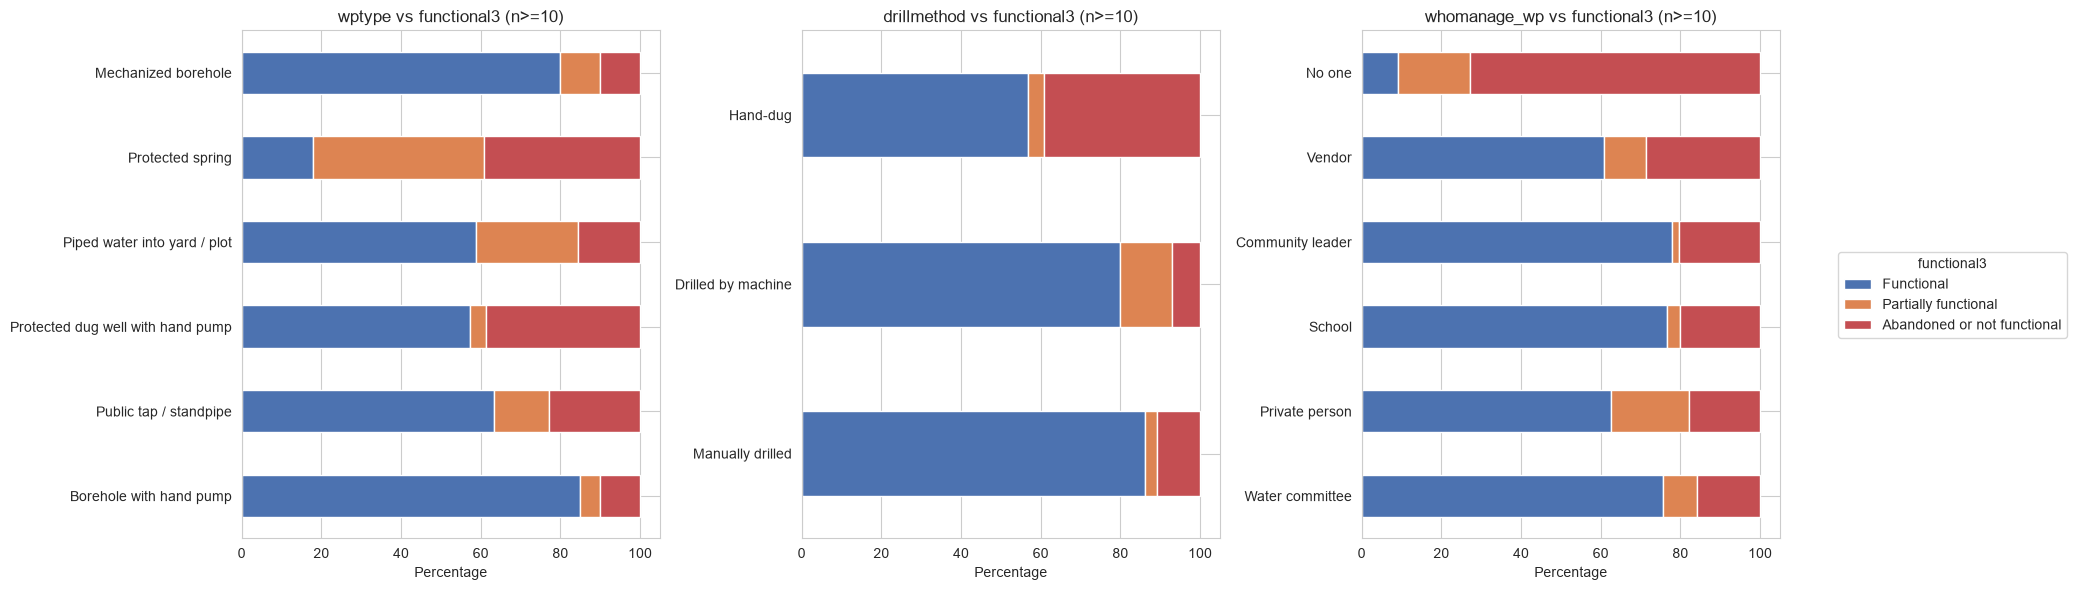

In [20]:
# wptype, drillmethod, whomanage_wp vs functional3 (column-normalized %, one subplot each)
cat_vs_target_cols = ["wptype", "drillmethod", "whomanage_wp"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, cat_vs_target_cols):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")[CLASS_ORDER] * 100
    # Only keep categories with a reasonable sample size for a readable chart
    counts = df[col].value_counts()
    ct = ct.loc[counts[counts >= 10].index]
    ct.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#C44E52"], legend=False)
    ax.set_title(f"{col} vs functional3 (n>=10)")
    ax.set_xlabel("Percentage")
    ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="functional3", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

**Observations (categories with n>=10 only, to avoid over-interpreting tiny samples):**
- `wptype`: "Protected spring" (n=28) has a much higher combined non-functional rate (39.3% abandoned + 42.9% partially functional) than the two dominant types, "Borehole with hand pump" (10.0% abandoned) and "Public tap / standpipe" (22.9% abandoned).
- `drillmethod`: "Hand-dug" (n=148) has notably worse functionality (39.2% abandoned) than "Manually drilled" (n=816, 10.9% abandoned) or "Drilled by machine" (n=228, 7.0% abandoned).
- `whomanage_wp`: "Water committee" (n=1,529, the dominant category) has a 75.6% functional rate; the small "No one" category (n=11) stands out sharply with only 9.1% functional and 72.7% abandoned — consistent with the intuitive idea that a lack of designated management is associated with poor upkeep, though the sample size here is very small.

In [21]:
# rehabyn and season vs functional3 — simple binary variables, a table is clearer than a chart
for col in ["rehabyn", "season"]:
    print(f"\n--- {col} vs {TARGET} (row %) ---")
    print((pd.crosstab(df[col], df[TARGET], normalize="index")[CLASS_ORDER] * 100).round(1))


--- rehabyn vs functional3 (row %) ---
functional3  Functional  Partially functional  Abandoned or not functional
rehabyn                                                                   
No                 78.0                   6.6                         15.5
Yes                72.6                   7.5                         19.9

--- season vs functional3 (row %) ---
functional3  Functional  Partially functional  Abandoned or not functional
season                                                                    
dry                73.3                   8.3                         18.4
wet                67.0                   8.5                         24.6


**Observation:** `rehabyn` and `season` both show only mild association with the target (functional rate 78.0% for "No" rehab vs 72.6% for "Yes"; 73.3% dry season vs 67.0% wet season). These differences are much smaller than what we see for `country`, `wptype`, or `drillmethod`, so they may be weaker predictors on their own.

### Numerical features vs target

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6752\3556971335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, ax=ax,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6752\3556971335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, ax=ax,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6752\3556971335.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, ax=ax,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6752\3556971335

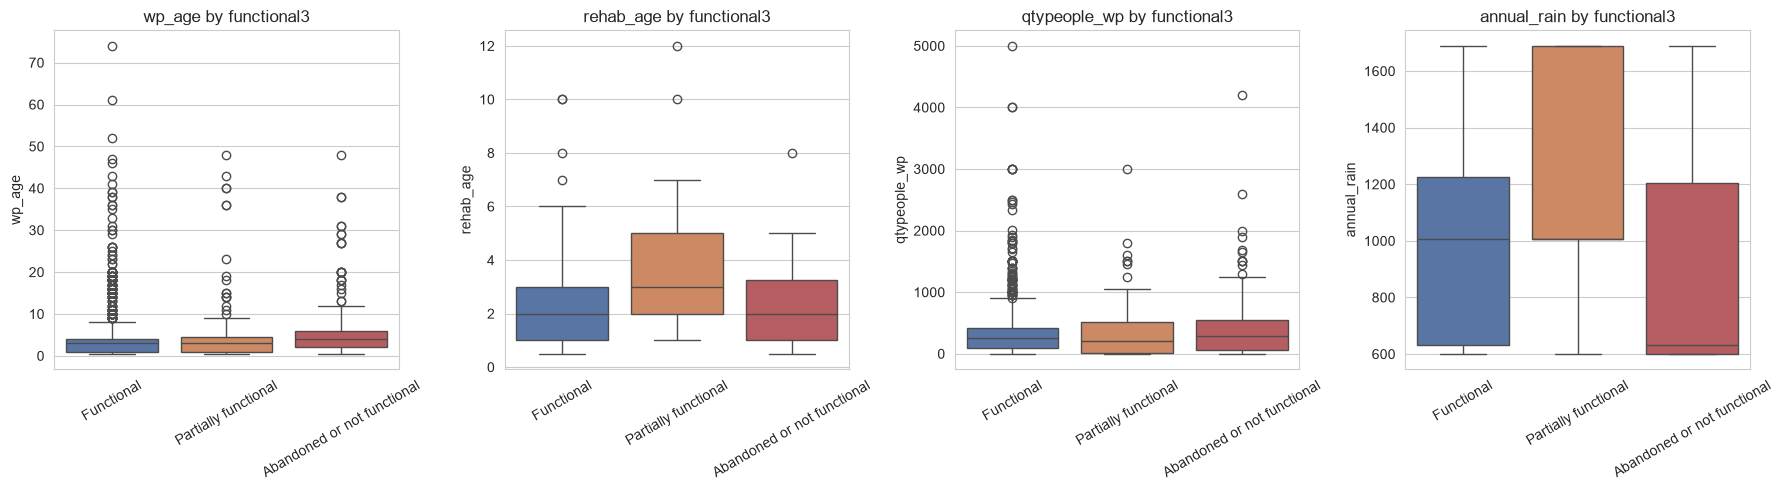

In [22]:
# wp_age, rehab_age, qtypeople_wp, annual_rain split by target class
num_vs_target_cols = ["wp_age", "rehab_age", "qtypeople_wp", "annual_rain"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, num_vs_target_cols):
    sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, ax=ax,
                palette=["#4C72B0", "#DD8452", "#C44E52"])
    ax.set_title(f"{col} by functional3")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observations:**
- `wp_age`: "Abandoned or not functional" water points are on average somewhat older (mean 5.53 years) than "Functional" ones (mean 4.35 years) — a mild pattern consistent with aging infrastructure being more likely to fail, though the spread within each group is large.
- `rehab_age`: Based on a much smaller sample (only records where `rehabyn` = "Yes"), "Partially functional" points have a notably higher mean time since rehabilitation (4.0 years, n=21) than "Functional" (2.34 years, n=203) or "Abandoned" (2.46 years, n=56). With only 21 partially-functional records here, this should be treated as a weak signal, not a firm conclusion.
- `qtypeople_wp`: Differences across classes are small (means range 321–394), suggesting the number of people served is not strongly associated with functionality on its own.
- `annual_rain`: Somewhat counterintuitively, "Partially functional" points average higher rainfall (1,158 mm) than "Functional" (1,000 mm) or "Abandoned" (921 mm) points — again based on a smaller sample (n=104 for partially functional) and worth revisiting rather than treated as conclusive.

# 11. Correlation Analysis

Compute pairwise correlations between numerical variables to spot redundant features and understand how variables relate to each other.

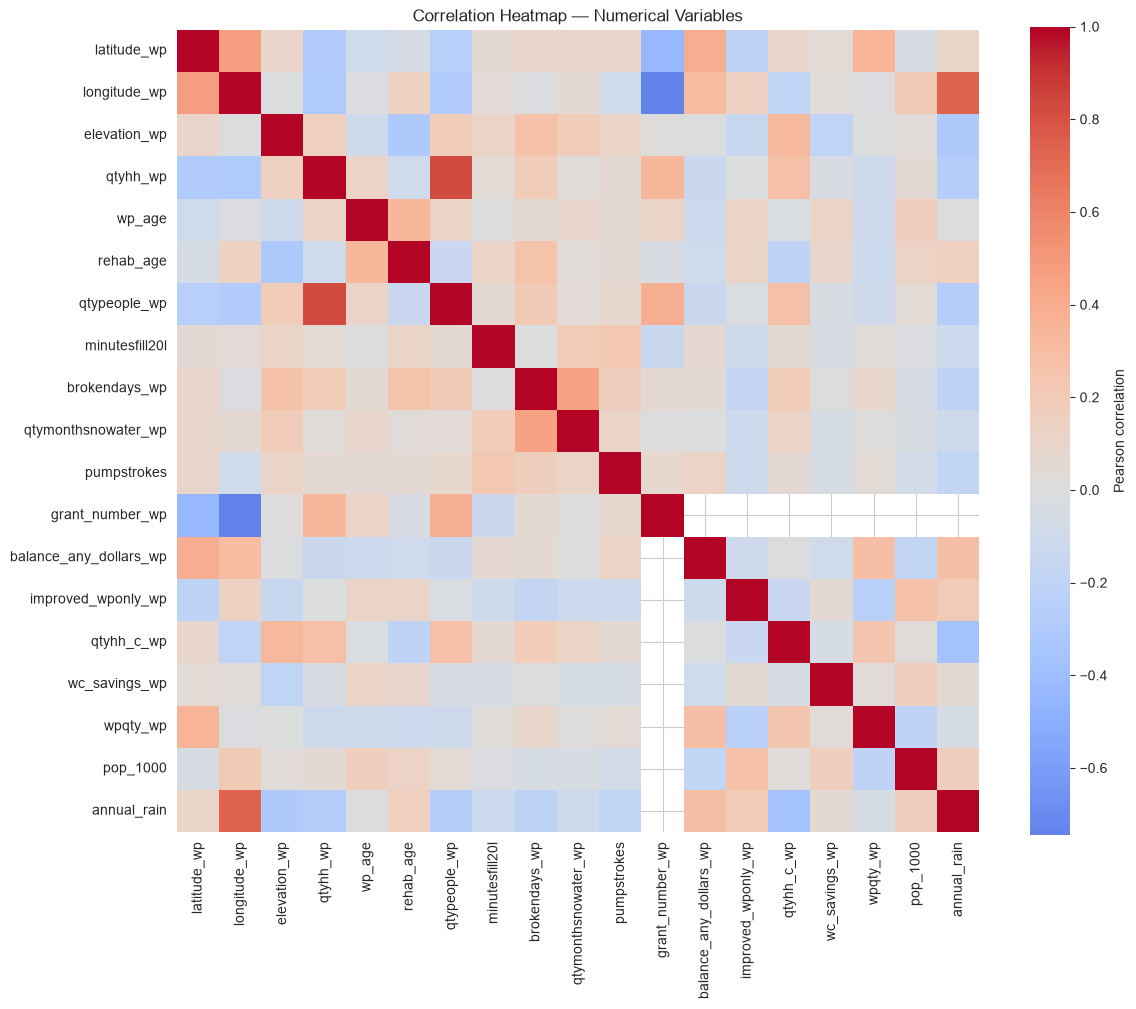

In [23]:
# Correlation heatmap for all numerical columns (excluding id)
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Variables")
plt.tight_layout()
plt.show()

In [24]:
# Top absolute correlations (excluding the diagonal), to spot the strongest relationships directly
corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(key=abs, ascending=False))
corr_pairs.head(10).to_frame("correlation")

correlation
qtyhh_wp      qtypeople_wp               0.818273
longitude_wp  grant_number_wp           -0.745615
              annual_rain                0.740830
latitude_wp   longitude_wp               0.477429
brokendays_wp qtymonthsnowater_wp        0.454844
latitude_wp   grant_number_wp           -0.444059
              balance_any_dollars_wp     0.396330
qtypeople_wp  grant_number_wp            0.382511
qtyhh_c_wp    annual_rain               -0.367241
latitude_wp   wpqty_wp                   0.354680

**Observations:**
- `qtyhh_wp` and `qtypeople_wp` are strongly correlated (r=0.82) — expected, since both describe the size of the population served by the same water point (households vs. people). These two are **redundant with each other** and are a candidate for feature selection later (e.g. keeping only one, or deriving average household size).
- `longitude_wp` shows strong correlations with `grant_number_wp` (r=-0.75) and `annual_rain` (r=0.74). These most likely reflect **geographic clustering** (specific countries/regions sit at particular longitudes, have particular rainfall patterns, and were funded under particular grant programs) rather than a direct causal relationship between longitude and these variables.
- Most other correlations are weak-to-moderate (|r| < 0.5), so beyond the `qtyhh_wp`/`qtypeople_wp` pair, multicollinearity does not look like a major concern among the remaining numerical variables.
- No numerical variable is highly correlated with `id`, as expected for an identifier.

No variables are removed at this stage — this is documented as input to feature selection during preprocessing.

# 12. Potential Data Leakage Investigation

`functional3` describes whether a water point is currently functional. Several variables in this dataset describe **current water availability and downtime** — since these are essentially *symptoms or direct components of* functionality itself, they risk **data leakage**: a model could achieve very high accuracy by reading these variables instead of learning genuinely predictive patterns from independent features (location, infrastructure type, age, management, etc.).

We investigate `wateravailable`, `minutesfill20l`, and `downtime2weeks` as instructed, plus other variables that show a similarly suspicious relationship with the target.

**No variables are removed in this notebook.** This section only documents evidence; the removal decision is made later, during feature selection.

In [25]:
# wateravailable vs functional3
pd.crosstab(df["wateravailable"], df[TARGET])

functional3,Abandoned or not functional,Functional,Partially functional
wateravailable,,,
No,300,0,2
Yes,3,1333,155


In [26]:
# downtime2weeks vs functional3
pd.crosstab(df["downtime2weeks"], df[TARGET])

functional3,Abandoned or not functional,Functional,Partially functional
downtime2weeks,,,
No,30,1332,76
Yes,272,1,81


In [27]:
# minutesfill20l ("time to fill a 20L container") by target class
df.groupby(TARGET)["minutesfill20l"].describe()

,count,mean,std,min,25%,50%,75%,max
functional3,,,,,,,,
Abandoned or not functional,1.0,8.383333,NaN,8.383333,8.383333,8.383333,8.383333,8.383333
Functional,1332.0,1.451739,0.727490,0.200000,1.000000,1.266667,1.666667,4.700000
Partially functional,140.0,98.423255,208.437753,0.633333,1.654167,5.333333,7.525000,555.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6752\3758519958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y="minutesfill20l", order=CLASS_ORDER, ax=axes[2],


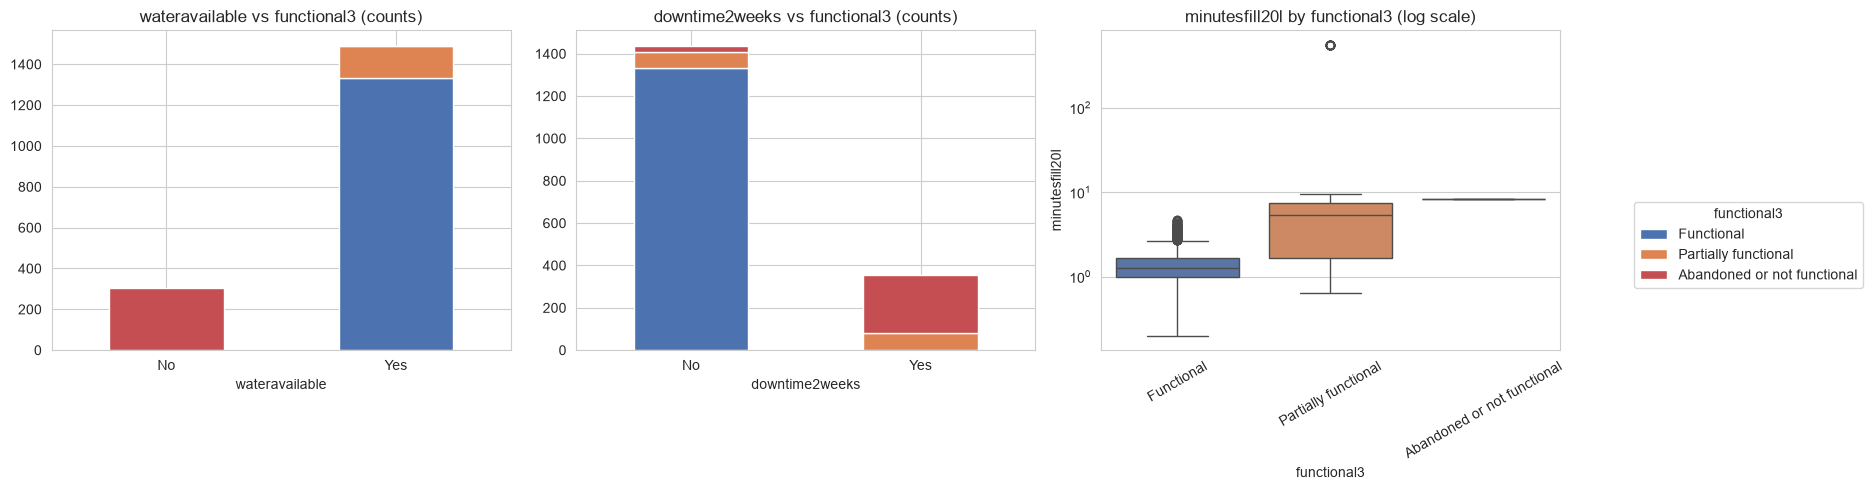

In [28]:
# Visualize how sharply these three variables separate the target classes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["wateravailable", "downtime2weeks"]):
    ct = pd.crosstab(df[col], df[TARGET])[CLASS_ORDER]
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#C44E52"], legend=False)
    ax.set_title(f"{col} vs functional3 (counts)")
    ax.tick_params(axis="x", rotation=0)

sns.boxplot(data=df, x=TARGET, y="minutesfill20l", order=CLASS_ORDER, ax=axes[2],
            palette=["#4C72B0", "#DD8452", "#C44E52"])
axes[2].set_yscale("log")
axes[2].set_title("minutesfill20l by functional3 (log scale)")
axes[2].tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="functional3", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

### Checking for other variables with a similarly suspicious relationship to the target

`wateravailable` and `downtime2weeks` are so cleanly split by class that it is worth checking whether **other "current status" variables** behave the same way.

In [29]:
# brokendays_wp ('days broken in the last period') by target
print("brokendays_wp by target:")
print(df.groupby(TARGET)["brokendays_wp"].describe()[["count", "mean", "50%", "max"]])

# qtymonthsnowater_wp ('months without water') by target
print("\nqtymonthsnowater_wp by target:")
print(df.groupby(TARGET)["qtymonthsnowater_wp"].describe()[["count", "mean", "50%", "max"]])

# whynowatertoday_wp: whether a 'reason for no water today' was recorded at all
print("\nwhynowatertoday_wp recorded (not missing) vs functional3:")
print(pd.crosstab(df["whynowatertoday_wp"].notna(), df[TARGET]))

# lockedfullday_wp vs target
print("\nlockedfullday_wp vs functional3:")
print(pd.crosstab(df["lockedfullday_wp"], df[TARGET]))

brokendays_wp by target:
                             count        mean    50%     max
functional3                                                  
Abandoned or not functional  200.0  429.770000  270.0  3650.0
Functional                   366.0   27.153005    7.0   510.0
Partially functional          67.0   49.970149    5.0  1460.0

qtymonthsnowater_wp by target:
                              count      mean  50%   max
functional3                                             
Abandoned or not functional   274.0  2.514599  0.0  12.0
Functional                   1227.0  0.125509  0.0   7.0
Partially functional          123.0  0.528455  0.0  12.0

whynowatertoday_wp recorded (not missing) vs functional3:
functional3         Abandoned or not functional  Functional  \
whynowatertoday_wp                                            
False                                         3        1333   
True                                        300           0   

functional3         Partially functi

### Potential Data Leakage

| Variable | Why it may cause leakage | Relationship to target (evidence) | Exclude from features? | Reason |
|---|---|---|---|---|
| `wateravailable` | Directly states whether water is currently available — essentially a restatement of functionality. | Near-perfect split: "No" -> 300 Abandoned + 2 Partially + 0 Functional; "Yes" -> 1,333 Functional + 155 Partially + 3 Abandoned. | **Yes** | Almost perfectly determines the target; using it would let a model "cheat" instead of learning from genuine predictors. |
| `whynowatertoday_wp` (and `whynowatertoday_wp_other`) | Only filled in when there currently is no water — its very presence/absence encodes the target. | Non-missing for 300/303 "Abandoned" and 2/157 "Partially functional" records, but 0/1,333 "Functional" records. | **Yes** | The missingness pattern alone almost perfectly reveals the target class; this is a textbook leakage-via-missingness case. |
| `downtime2weeks` | States whether the water point was down at all in the last two weeks — a short-term functionality symptom. | "Yes" -> 272 Abandoned + 81 Partially + 1 Functional; "No" -> 30 Abandoned + 76 Partially + 1,332 Functional. | **Yes** | Extremely cleanly separates the classes; recent downtime is essentially part of how functionality would be defined/observed in the field. |
| `minutesfill20l` | Measures how slowly water flows — a direct symptom of a struggling or non-functional source. | Mean time is 1.45 min for "Functional" vs. 98.4 min for "Partially functional" (up to 555 min); almost no data for "Abandoned" (only 1 non-null value, since there is no water to time). | **Yes** | Both its value and its very high missingness for "Abandoned" records are driven directly by functionality status. |
| `brokendays_wp` | Counts days the water point was broken — a direct downtime measurement. | Mean 429.8 days for "Abandoned" vs. 27.2 days for "Functional" vs. 50.0 days for "Partially functional". | **Yes** | An order-of-magnitude difference between classes; this variable is essentially a quantified description of non-functionality. |
| `qtymonthsnowater_wp` | Counts months without water — another direct downtime measurement. | Mean 2.51 months for "Abandoned" vs. 0.13 for "Functional" vs. 0.53 for "Partially functional". | **Yes** | Same reasoning as `brokendays_wp`: a numeric symptom of the target rather than an independent predictor. |
| `lockedfullday_wp` | Describes daily access restriction, not functionality directly. | Roughly similar class proportions whether "No" (18.4% abandoned) or "Yes" (11.7% abandoned) — no sharp separation. | No (based on current evidence) | Does not show the same near-perfect separation as the variables above; appears to be a genuine, independent operational attribute rather than a leakage source. |

**Summary:** `wateravailable`, `whynowatertoday_wp` (+ its `_other` free-text field), `downtime2weeks`, `minutesfill20l`, `brokendays_wp`, and `qtymonthsnowater_wp` all describe **current or recent water availability/downtime**, which is essentially what `functional3` is measuring. Including them as predictive features would let a model learn the target from a restatement of itself rather than from genuinely independent water-point characteristics (location, infrastructure, age, management, rainfall, etc.). The final decision to exclude them is deferred to the preprocessing/feature-selection stage, as instructed, but the evidence collected here strongly supports excluding all six from the predictive feature set.

# 13. Key EDA Findings

### Dataset Structure
- 1,793 rows and 52 columns; 1 identifier (`id`), 32 categorical (`str`) columns, 19 numerical (`float64`) columns, and the target `functional3`.

### Target Distribution
- Strongly imbalanced: Functional 1,333 (74.34%), Abandoned or not functional 303 (16.90%), Partially functional 157 (8.76%).

### Missing Values
- 40 of 52 columns have missing values, ranging from 0.06% (`downtime2weeks`, `whomanage_wp`) up to 99.0% (`whynowatertoday_wp_other`).
- Much of the heavy missingness is **structural, not random**: e.g. `rehab_age` is missing for 100% of records where `rehabyn` = "No" (it doesn't apply), and `whynowatertoday_wp` is only ever filled in when water is currently unavailable.

### Duplicates
- No fully duplicated rows (0.0%).

### Numerical Variables
- `wp_age`, `qtypeople_wp`, and `qtyhh_wp` are strongly right-skewed (skew 3.3–4.1); most water points are young and modest in scale, with a long tail of larger/older sites.
- `annual_rain` and `elevation_wp` are closer to symmetric.
- `elevation_wp` has 107 negative values (106 of them in West Bengal, India), which looks like a systematic data-quality artifact rather than genuine below-sea-level measurements.

### Categorical Variables
- `wptype` and `whomanage_wp` are both dominated by a single category ("Borehole with hand pump", "Water committee") with several very rare categories (n < 5).
- `pumptype`, `drillmethod`, `piped_source`, and `piped_pump` have high missingness that reflects **conditional applicability** (e.g. a protected spring has no pump type), not random data loss.

### Outliers
- No values were removed. Several variables (`qtypeople_wp`, `qtyhh_wp`, `minutesfill20l`, `pumpstrokes`) have extreme values classified as "requires further investigation"; `wp_age`, `brokendays_wp`, and `pop_1000` extremes look like plausible real-world values; `elevation_wp`'s negative values look like a potential data-quality issue concentrated in one region.

### Feature Relationships
- `country` shows a strong association with functionality (Ethiopia: 31.9% abandoned vs. Mozambique: 2.6%).
- `drillmethod` ("Hand-dug" 39.2% abandoned vs. "Manually drilled" 10.9%) and `wptype` ("Protected spring" 42.9% partially functional) also show clear differences.
- `whomanage_wp` = "No one" (n=11) has a strikingly high abandonment rate (72.7%), though the sample is very small.
- `rehabyn` and `season` show only mild association with the target.

### Correlations
- `qtyhh_wp` and `qtypeople_wp` are strongly correlated (r=0.82) — likely redundant.
- `longitude_wp` correlates strongly with `grant_number_wp` (r=-0.75) and `annual_rain` (r=0.74), most likely reflecting geographic clustering rather than a direct relationship.

### Data Leakage Risks
- `wateravailable`, `whynowatertoday_wp` (+ `_other`), `downtime2weeks`, `minutesfill20l`, `brokendays_wp`, and `qtymonthsnowater_wp` all show near-perfect or very strong separation of the target classes because they directly describe current/recent water availability — the same thing `functional3` measures. These are strong candidates for exclusion from the predictive feature set.

# 14. Implications for Preprocessing

These are considerations for the **next** stage, not decisions made here:

- **Missing-value treatment:** A single blanket strategy (e.g. mean/mode imputation for everything) would be inappropriate. Structurally-missing columns (`rehab_age`, `pumptype`, `drillmethod`, `piped_source`, `piped_pump`, etc.) may be better handled with an explicit "Not applicable" category or a missingness indicator, rather than imputing a value that implies the condition applies. Columns with extremely high missingness (e.g. `whynowatertoday_wp_other` at 99.0%) may need to be dropped rather than imputed — a decision to make explicitly during preprocessing.
- **Categorical encoding:** Variables like `country`, `wptype`, `pumptype`, `drillmethod`, and `whomanage_wp` will need an encoding strategy that accounts for very rare categories (some with n < 5), which can be unstable for models if encoded naively (e.g. one-hot encoding creating near-empty columns).
- **Numerical scaling:** `wp_age`, `qtypeople_wp`, `qtyhh_wp`, and `pop_1000` are highly skewed, which may warrant a transformation (e.g. log) depending on the modeling algorithm chosen, in addition to any scaling.
- **Outlier treatment:** Variables flagged as "requires further investigation" (`qtypeople_wp`, `qtyhh_wp`, `minutesfill20l`, `pumpstrokes`) need a decision on whether extreme values are genuine or should be capped/transformed. The negative `elevation_wp` values concentrated in West Bengal warrant checking against an external elevation source before deciding whether to correct, cap, or leave them.
- **Feature selection:** `qtyhh_wp` and `qtypeople_wp` are highly correlated (r=0.82) and may not both be needed. High-cardinality/identifier-like columns (e.g. `cwid`, `commid_wp`) should be reviewed for predictive value versus leakage/overfitting risk.
- **Class imbalance handling:** With "Partially functional" at only 8.76% of records, evaluation should rely on metrics beyond accuracy (e.g. macro F1, per-class recall/precision, confusion matrix), and resampling or class-weighting strategies should be considered and evaluated rather than assumed necessary.
- **Leakage prevention:** `wateravailable`, `whynowatertoday_wp` (+ `_other`), `downtime2weeks`, `minutesfill20l`, `brokendays_wp`, and `qtymonthsnowater_wp` show evidence strong enough that they should very likely be **excluded from the predictive feature set** before model training — this decision should be finalized and documented explicitly in the preprocessing/feature-selection notebook.

No preprocessing steps above have been implemented in this notebook — they are documented here purely as considerations for the next stage.